# Attention and the Transformer Architecture
You are part of a product team tasked with improving a translation service. While your previous LSTMs (from Practical 4) worked, they struggled with very long sentences, often forgetting the early context. The management wants to upgrade the system using the Attention Mechanism to focus on the most relevant parts of the source sentence, followed by migrating to the state-of-the-art Transformer architecture.
Your task is to implement the core mathematical concept of Attention and then use a pre-trained Transformer to demonstrate its power in a practical application.

In [ ]:
# Import

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Part A: Implementing Dot-Product Attention (The Core Math)

### Task A.1: The QKV Interaction
Implement a Python function `dot_product_attention(Q, K, V, mask=None)`:

1. Calculate the Attention Scores by taking the dot product of the Query (Q) and the Key (K), and scaling by :
    * Action: Use `torch.bmm` or matrix multiplication.
2. Apply a Softmax function over the scores to obtain the Attention Weights.

3. Calculate the final Context Vector by multiplying the weights by the Value (V) matrix.


In [ ]:
def dot_product_attention(Q, K, V, mask=None):
    # 1. Compute scaled dot-product attention scores
    d_k = Q.size(-1)
    scores = torch.bmm(Q, K.transpose(1, 2)) / math.sqrt(d_k)
    
    # 2. Apply mask (if provided)
    if mask is not None:
        # Replace masked positions with a very large negative number
        scores = scores.masked_fill(mask == 0, float('-inf'))
    
    # 3. Apply softmax to get attention weights
    weights = F.softmax(scores, dim=-1)
    
    # 4. Multiply weights with values to get context vectors
    context = torch.bmm(weights, V)
    
    return context, weights

In [ ]:
def test_attention():
    torch.manual_seed(42)  # For reproducibility

    batch_size = 2
    seq_len_q = 3
    seq_len_k = 4
    d_k = 5
    d_v = 6

    # Random tensors
    Q = torch.randn(batch_size, seq_len_q, d_k)
    K = torch.randn(batch_size, seq_len_k, d_k)
    V = torch.randn(batch_size, seq_len_k, d_v)

    context, weights = dot_product_attention(Q, K, V)

    print("Q shape:", Q.shape)
    print("K shape:", K.shape)
    print("V shape:", V.shape)
    print("\nAttention Weights shape:", weights.shape)
    print("Context shape:", context.shape)

    # Check softmax property
    print("\nSum of attention weights (should be 1):")
    print(weights.sum(dim=-1))

    # Example mask (masking last key position)
    mask = torch.ones(batch_size, seq_len_q, seq_len_k)
    mask[:, :, -1] = 0

    context_masked, weights_masked = dot_product_attention(Q, K, V, mask)

    print("\nMasked attention weights (last column should be ~0):")
    print(weights_masked)



test_attention()

Q shape: torch.Size([2, 3, 5])
K shape: torch.Size([2, 4, 5])
V shape: torch.Size([2, 4, 6])

Attention Weights shape: torch.Size([2, 3, 4])
Context shape: torch.Size([2, 3, 6])

Sum of attention weights (should be 1):
tensor([[1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000]])

Masked attention weights (last column should be ~0):
tensor([[[0.0790, 0.8913, 0.0297, 0.0000],
         [0.7132, 0.0302, 0.2565, 0.0000],
         [0.2799, 0.5694, 0.1507, 0.0000]],

        [[0.2982, 0.4433, 0.2585, 0.0000],
         [0.2345, 0.2617, 0.5039, 0.0000],
         [0.6128, 0.3037, 0.0835, 0.0000]]])


### Task A.2: Visualizing Attention
Select a short example sentence and manually create mock Q, K, and V tensors.
1. Run the `dot_product_attention` function.
2. Visualize the generated Attention Weights Matrix (e.g., using a heatmap from `matplotlib` or `seaborn`). This plot should demonstrate which input words the model is focusing on when calculating the output for a specific word.


Query Shape: torch.Size([1, 3, 4])
Key Shape:   torch.Size([1, 3, 4])
Value Shape: torch.Size([1, 3, 4])

Calculated Attention Weights:
tensor([[[0.3017, 0.3098, 0.3884],
         [0.2451, 0.3801, 0.3748],
         [0.2938, 0.2293, 0.4769]]])

Generating Visualization...


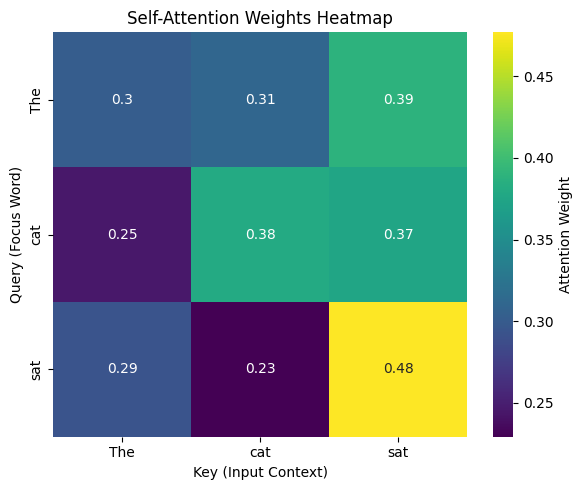

In [ ]:
def visualize_attention(weights, tokens):
    """
    weights: (1, seq_len, seq_len)
    tokens: list of token strings
    """
    # Remove batch dimension
    weights = weights.squeeze(0).detach().numpy()
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        weights,
        annot=True,
        cmap="viridis",
        xticklabels=tokens,
        yticklabels=tokens,
        cbar_kws={'label': 'Attention Weight'}
    )
    
    plt.xlabel("Key (Input Context)")
    plt.ylabel("Query (Focus Word)")
    plt.title("Self-Attention Weights Heatmap")
    plt.tight_layout()
    plt.show()


torch.manual_seed(42)

sentence = ["The", "cat", "sat"]
batch_size = 1
seq_len = len(sentence)
d_k = 4

# Random mock Q, K, V
Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)

print("Query Shape:", Q.shape)
print("Key Shape:  ", K.shape)
print("Value Shape:", V.shape)


context, weights = dot_product_attention(Q, K, V)

print("\nCalculated Attention Weights:")
print(weights)


print("\nGenerating Visualization...")
visualize_attention(weights, sentence)

## Part B: Applying a Pre-trained Transformer

### Task B.1: Zero-Shot Sequence-to-Sequence (Translation)
Leverage the Hugging Face transformers library, which utilizes the full architecture (Encoder-Decoder) described in the "Attention is All You Need" paper.

1. Load a pre-trained Seq2Seq model, such as **T5** (`t5-small`) or **mBART** (`mbart-large-50`), and its corresponding tokenizer.
    * Action: Use `AutoTokenizer.from_pretrained(...)` and `AutoModelForSeq2SeqLM.from_pretrained(...)`.
2. Perform a **zero-shot translation** (e.g., `English to German/French`) on a sample sentence. You must correctly format the input prompt, including the task instruction (e.g., "`translate English to German: ...`" for T5).
3. Use the model's `generate()` method to obtain the translated output.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast

c:\Users\vedan\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def translate_text(text, source_lang="English", target_lang="German"):
    model_name = "t5-small"
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    
    # Format input with task prefix
    input_text = f"translate {source_lang} to {target_lang}: {text}"
    
    inputs = tokenizer(input_text, return_tensors="pt")
    
    outputs = model.generate(
        **inputs,
        max_length=100,
        num_beams=4,
        early_stopping=True
    )
    
    translated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    return translated_text

In [ ]:
def translate_with_mbart(text, target_lang_code="de_DE"):
    model_name = "facebook/mbart-large-50-many-to-many-mmt"
    
    tokenizer = MBart50TokenizerFast.from_pretrained(model_name)
    model = MBartForConditionalGeneration.from_pretrained(model_name)
    
    # Set source language (English)
    tokenizer.src_lang = "en_XX"
    
    encoded = tokenizer(text, return_tensors="pt")
    
    generated_tokens = model.generate(
        **encoded,
        forced_bos_token_id=tokenizer.lang_code_to_id[target_lang_code],
        max_length=100,
        num_beams=4
    )
    
    translated_text = tokenizer.batch_decode(
        generated_tokens, skip_special_tokens=True
    )[0]
    
    return translated_text

In [ ]:
# Sample Sentence
english_text = "The transformer model is powerful and efficient."

# Perform Translation
german_translation = translate_text(english_text, target_lang="German")
french_translation = translate_text(english_text, target_lang="French")

print(f"-" * 30)
print(f"Original: {english_text}")
print(f"German:   {german_translation}")
print(f"French:   {french_translation}")


# Translate to German (de_DE)
german_translation = translate_with_mbart(english_text, target_lang_code="de_DE")

# Translate to French (fr_XX)
french_translation = translate_with_mbart(english_text, target_lang_code="fr_XX")

print(f"-" * 30)
print(f"Original: {english_text}")
print(f"German:   {german_translation}")
print(f"French:   {french_translation}")

------------------------------
Original: The transformer model is powerful and efficient.
German:   Das Transformatormodell ist leistungsstark und effizient.
French:   Le modèle de transformateur est puissant et efficace.


ValueError: Converting from SentencePiece and Tiktoken failed, if a converter for SentencePiece is available, provide a model path with a SentencePiece tokenizer.model file.Currently available slow->fast converters: ['AlbertTokenizer', 'BartTokenizer', 'BarthezTokenizer', 'BertTokenizer', 'BigBirdTokenizer', 'BlenderbotTokenizer', 'CamembertTokenizer', 'CLIPTokenizer', 'CodeGenTokenizer', 'ConvBertTokenizer', 'DebertaTokenizer', 'DebertaV2Tokenizer', 'DistilBertTokenizer', 'DPRReaderTokenizer', 'DPRQuestionEncoderTokenizer', 'DPRContextEncoderTokenizer', 'ElectraTokenizer', 'FNetTokenizer', 'FunnelTokenizer', 'GPT2Tokenizer', 'HerbertTokenizer', 'LayoutLMTokenizer', 'LayoutLMv2Tokenizer', 'LayoutLMv3Tokenizer', 'LayoutXLMTokenizer', 'LongformerTokenizer', 'LEDTokenizer', 'LxmertTokenizer', 'MarkupLMTokenizer', 'MBartTokenizer', 'MBart50Tokenizer', 'MPNetTokenizer', 'MobileBertTokenizer', 'MvpTokenizer', 'NllbTokenizer', 'OpenAIGPTTokenizer', 'PegasusTokenizer', 'Qwen2Tokenizer', 'Realm

### Task B.2: The Need for Positional Encoding (Theoretical)
The Transformer removes the sequential processing of RNNs, making all tokens independent. Explain (in a brief text block in the notebook) why this is a problem and how Positional Encoding (a fixed or learned vector added to the word embedding) is essential to re-introduce the notion of word order into the model.


In [ ]:
# Answer

## Deliverables
1. A fully executed Python Notebook (.ipynb) implementing the Dot-Product Attention function and the zero-shot translation using a Hugging Face Transformer model.
2. **Visualization:** The heatmap of the Attention Weights Matrix from Task A.2.
3. **Analysis:** A concise answer (approx. 100 words) to the question: What is the primary computational advantage of using Self-Attention (within the Transformer) over the Recurrent connection (in LSTMs) when processing long sequences? (Hint: Think about parallel processing).
